# 09. Contextual Anchor: OCV Rest vs History

After the anchor trap appeared, the next question was whether additional causal context could repair the initial SOC estimate. Sprint 50 injected contextual features into the anchor branch only: OCV-rest evidence, 60 s current/voltage history, or both.

The result is the key observability lesson. Dynamic history alone is not an absolute SOC reference. It can describe recent load and voltage sag, but at `-20 C` that history is polluted by polarization and current-dependent voltage depression. The history-only anchor therefore becomes worse. In contrast, valid rest evidence approximates an OCV anchor, so OCV-rest-only improves MaxE and RMSE.

This is not a Coulomb-layer failure. PVR remains `0.00%` across context variants. The remaining error is the anchor's inability to observe absolute SOC from dynamic voltage history at cold temperature.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and outputs/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})
print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load Sprint 50 contextual-anchor results

The target temperature is `n20degC` (`-20 C`) under Scenario A OOD testing. The table below uses the saved Sprint 50 scientific-test ledger directly.


In [2]:
log_path = ROOT / 'outputs' / 'v5_contextual' / 'sprint50_contextual' / 'sprint50_contextual_results.json'
if not log_path.exists():
    raise FileNotFoundError(log_path)
payload = json.loads(log_path.read_text(encoding='utf-8'))
ctx_df = pd.DataFrame(payload['scientific_test'])
order = ['empty_anchor_ctx', 'ocv_rest_only', 'history_only', 'full_context']
ctx_df['order'] = ctx_df['ablation'].map({name: i for i, name in enumerate(order)})
ctx_df = ctx_df.sort_values('order').drop(columns='order')
ctx_df = ctx_df.rename(columns={
    'label': 'Context variant',
    'full_rmse_pct': 'Full RMSE (%)',
    'full_maxe_pct': 'Full MaxE (%)',
    't0_rmse_pct': 't0 RMSE (%)',
    't0_maxe_pct': 't0 MaxE (%)',
    'pvr_pct': 'PVR (%)',
})
display(ctx_df[['ablation', 'Context variant', 'target_temp', 'n_windows', 't0 RMSE (%)', 't0 MaxE (%)', 'Full RMSE (%)', 'Full MaxE (%)', 'PVR (%)']].round(3))

metrics = {row['ablation']: row for _, row in ctx_df.iterrows()}
assert metrics['ocv_rest_only']['Full MaxE (%)'] < metrics['empty_anchor_ctx']['Full MaxE (%)'], 'OCV-rest should improve MaxE versus empty context.'
assert metrics['history_only']['Full MaxE (%)'] > metrics['empty_anchor_ctx']['Full MaxE (%)'], 'History-only should be worse than empty context.'
assert (ctx_df['PVR (%)'] == 0.0).all(), 'Contextual Hard-Coulomb variants should preserve zero PVR.'


,ablation,Context variant,target_temp,n_windows,t0 RMSE (%),t0 MaxE (%),Full RMSE (%),Full MaxE (%),PVR (%)
0,empty_anchor_ctx,HC-LSTM Empty Anchor Ctx,n20degC,5289,17.284,52.509,17.091,52.704,0.0
1,ocv_rest_only,+OCV-rest only,n20degC,5289,13.888,46.360,13.941,47.184,0.0
2,history_only,+History only,n20degC,5289,23.123,61.830,22.894,62.131,0.0
3,full_context,+OCV-rest + History,n20degC,5289,17.984,52.907,17.497,52.907,0.0


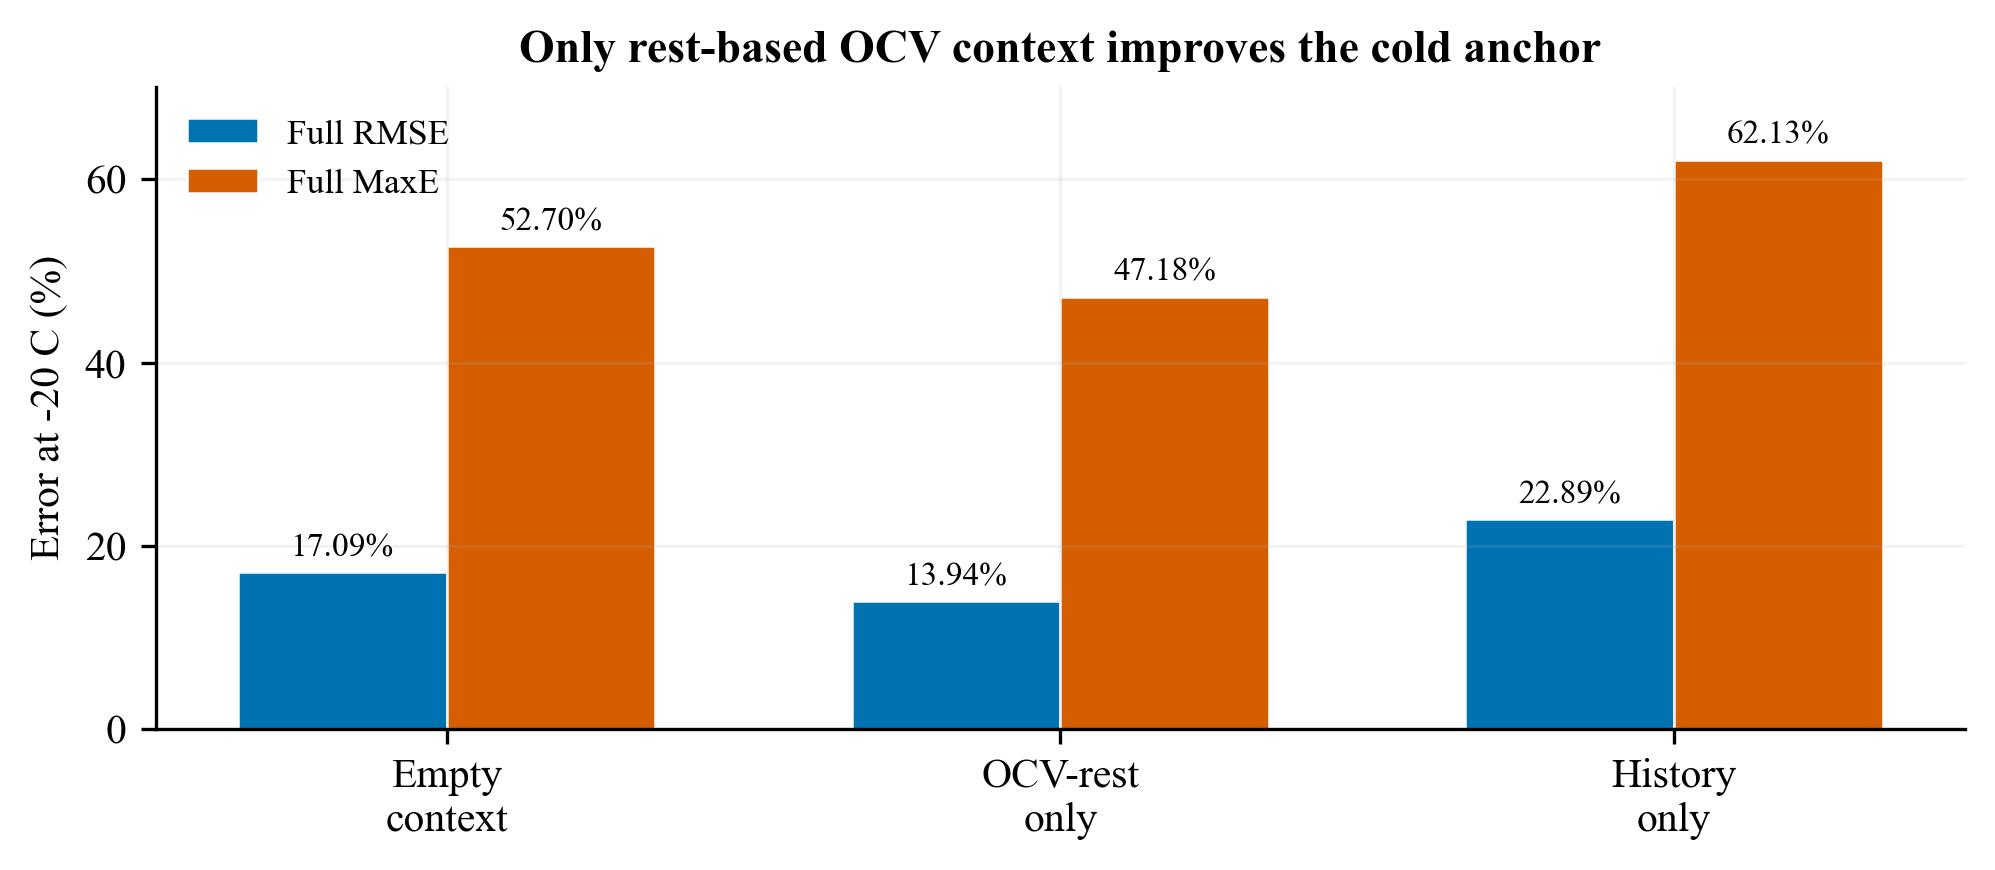

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_09_contextual_anchor_ocv_vs_history.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_09_contextual_anchor_ocv_vs_history.png


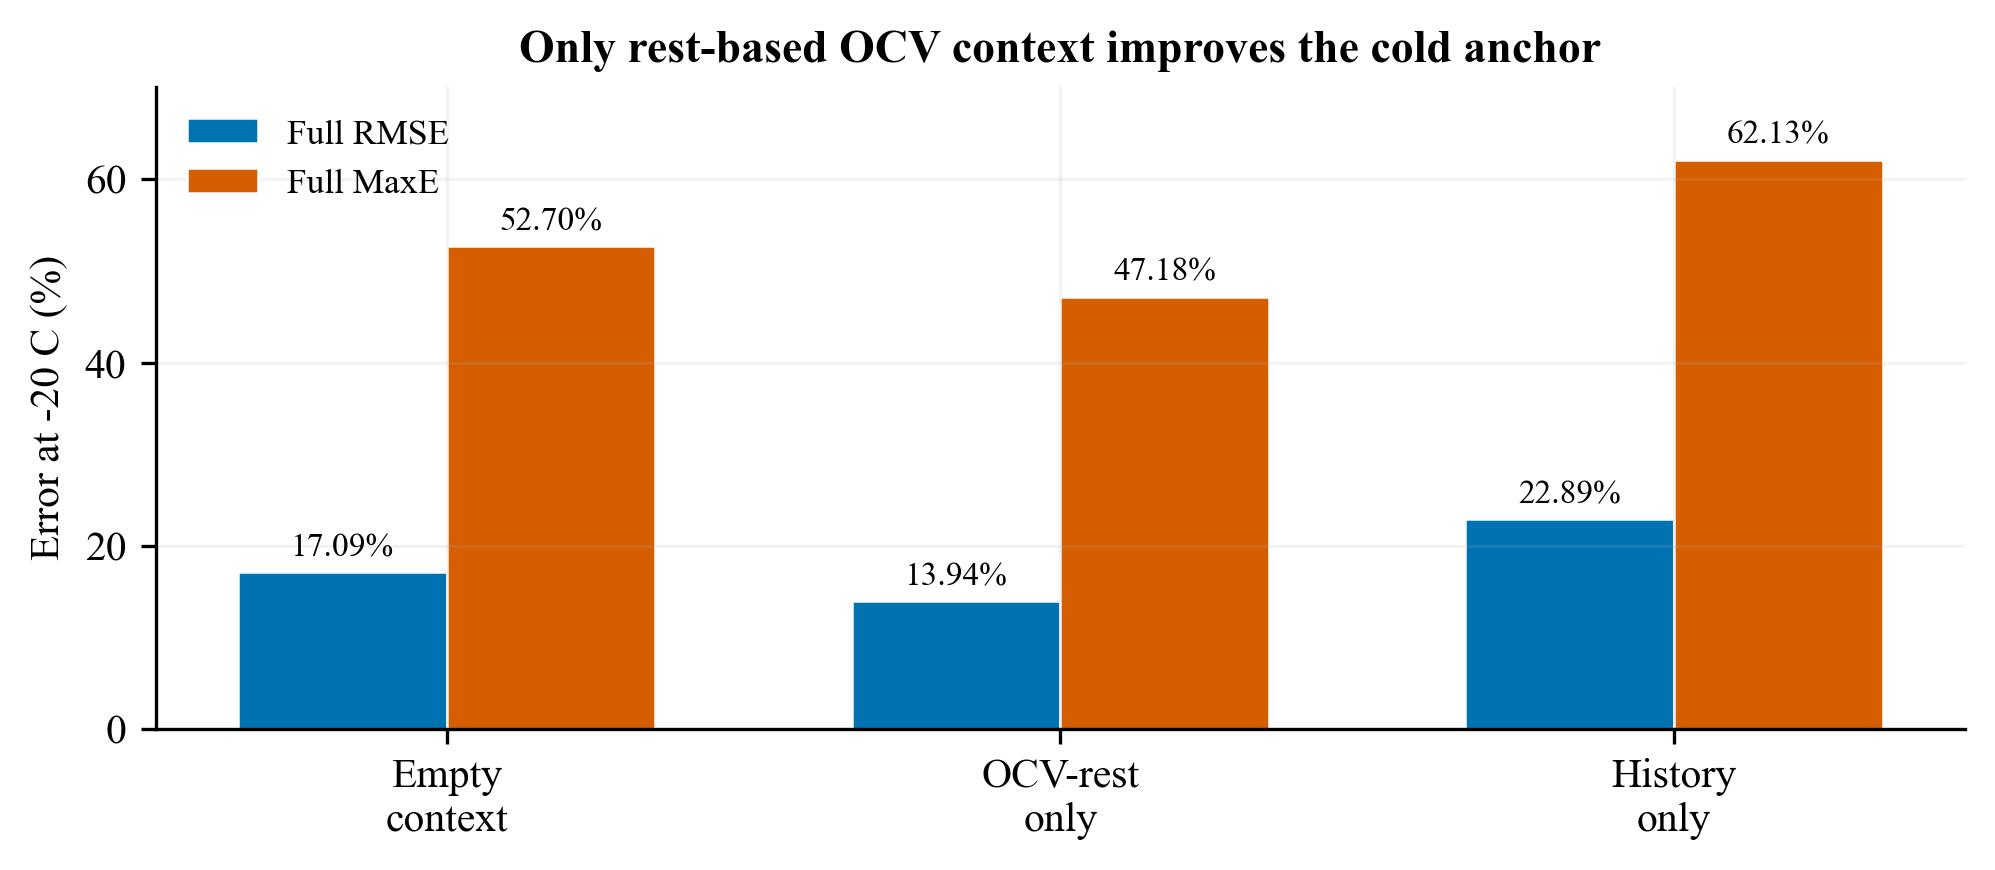

In [3]:
plot_df = ctx_df[ctx_df['ablation'].isin(['empty_anchor_ctx', 'ocv_rest_only', 'history_only'])].copy()
labels = ['Empty\ncontext', 'OCV-rest\nonly', 'History\nonly']
x = np.arange(len(plot_df))
width = 0.34
fig, ax = plt.subplots(figsize=(6.75, 3.0))
bars1 = ax.bar(x - width/2, plot_df['Full RMSE (%)'], width=width, color='#0072B2', edgecolor='white', linewidth=0.6, label='Full RMSE')
bars2 = ax.bar(x + width/2, plot_df['Full MaxE (%)'], width=width, color='#D55E00', edgecolor='white', linewidth=0.6, label='Full MaxE')
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, value + 1.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Error at -20 C (%)')
ax.set_ylim(0, max(plot_df['Full MaxE (%)'].max() + 8.0, 70.0))
ax.set_title('Only rest-based OCV context improves the cold anchor')
ax.legend(loc='upper left')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_09_contextual_anchor_ocv_vs_history.pdf'
png_path = FIG_DIR / 'fig_09_contextual_anchor_ocv_vs_history.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

History-only context is not an anchor because it lacks absolute thermodynamic reference. OCV-rest-only improves because rest voltage is closer to equilibrium and therefore carries usable SOC information. Full context does not rescue the model because the history branch can reintroduce dynamic polarization noise.
